## Survived Predict with Classification Algorithms

Hello :) I'm recently learning data science and machine learning algorithms. I'm working making practice what I learn. I used python language and Titanic Disaster dataset. I hope it's benefit for you. Please consider upvoting if this is useful to you! :) 

### CONTENTS:
[1. Exploratory Data Analysis](#1) <br/>
[2. Cleaning Data](#2) <br/>
[3. Classification Algorithms](#3) <br/>
&nbsp;&nbsp;&nbsp; [A. Logistic Regression Algorithm](#3.1) <br/>
&nbsp;&nbsp;&nbsp; [B. K-Nearest Neighbour (KNN) Algorithm](#3.2) <br/>
&nbsp;&nbsp;&nbsp; [C. Support Vector Machine (SVM) Algorithm](#3.3) <br/>
&nbsp;&nbsp;&nbsp; [D. Naive Bayes Algorithm](#3.4) <br/>
&nbsp;&nbsp;&nbsp; [E. Decision Tree Algorithm](#3.5) <br/>
&nbsp;&nbsp;&nbsp; [F. Random Forest Algorithm](#3.6) <br/>
&nbsp;&nbsp;&nbsp; [G. Evaluation Classification Models](#3.7) <br/>

<a id="1"></a>
### 1. Exploratory Data Analysis

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# data visualization
import seaborn as sns 
import matplotlib.pyplot as plt

import os
print(os.listdir("../input"))

['test.csv', 'train.csv', 'gender_submission.csv']


In [2]:
#read data
data_train = pd.read_csv("../input/train.csv")
data_test = pd.read_csv("../input/test.csv")

In [3]:
#train sample
data_train.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
615,616,1,2,"Herman, Miss. Alice",female,24.0,1,2,220845,65.0000,NaN,S
227,228,0,3,"Lovell, Mr. John Hall (""Henry"")",male,20.5,0,0,A/5 21173,7.2500,NaN,S
599,600,1,1,"Duff Gordon, Sir. Cosmo Edmund (""Mr Morgan"")",male,49.0,1,0,PC 17485,56.9292,A20,C
489,490,1,3,"Coutts, Master. Eden Leslie ""Neville""",male,9.0,1,1,C.A. 37671,15.9000,NaN,S
449,450,1,1,"Peuchen, Major. Arthur Godfrey",male,52.0,0,0,113786,30.5000,C104,S


In [4]:
#test sample
data_test.sample(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
118,1010,1,"Beattie, Mr. Thomson",male,36.0,0,0,13050,75.2417,C6,C
388,1280,3,"Canavan, Mr. Patrick",male,21.0,0,0,364858,7.7500,NaN,Q
210,1102,3,"Andersen, Mr. Albert Karvin",male,32.0,0,0,C 4001,22.5250,NaN,S
156,1048,1,"Bird, Miss. Ellen",female,29.0,0,0,PC 17483,221.7792,C97,S
306,1198,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0,1,2,113781,151.5500,C22 C26,S


In [5]:
data_train.info()
print("---------------------------------")
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Name           891 non-null object
Sex            891 non-null object
Age            714 non-null float64
SibSp          891 non-null int64
Parch          891 non-null int64
Ticket         891 non-null object
Fare           891 non-null float64
Cabin          204 non-null object
Embarked       889 non-null object
dtypes: float64(2), int64(5), object(5)
memory usage: 83.6+ KB
---------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
PassengerId    418 non-null int64
Pclass         418 non-null int64
Name           418 non-null object
Sex            418 non-null object
Age            332 non-null float64
SibSp          418 non-null int64
Parch          418 non-null int64
Ticket         418 non-null object

In [6]:
#train columns
data_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [7]:
#test column
data_test.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
data_train.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Mamee, Mr. Hanna",male,NaN,NaN,NaN,CA. 2343,NaN,C23 C25 C27,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [9]:
data_test.describe(include="all")

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,418.000000,418.000000,418,418,332.000000,418.000000,418.000000,418,417.000000,91,418
unique,NaN,NaN,418,2,NaN,NaN,NaN,363,NaN,76,3
top,NaN,NaN,"Compton, Mrs. Alexander Taylor (Mary Eliza Ing...",male,NaN,NaN,NaN,PC 17608,NaN,B57 B59 B63 B66,S
freq,NaN,NaN,1,266,NaN,NaN,NaN,5,NaN,3,270
mean,1100.500000,2.265550,NaN,NaN,30.272590,0.447368,0.392344,NaN,35.627188,NaN,NaN
std,120.810458,0.841838,NaN,NaN,14.181209,0.896760,0.981429,NaN,55.907576,NaN,NaN
min,892.000000,1.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,996.250000,1.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN
50%,1100.500000,3.000000,NaN,NaN,27.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,1204.750000,3.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.500000,NaN,NaN


In [10]:
#missing values
print(pd.isnull(data_train).sum())
print("-------------------------")
print(pd.isnull(data_test).sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
-------------------------
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


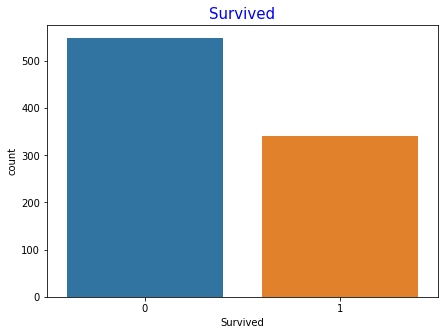

In [11]:
# train survived count
survived = data_train.Survived
plt.figure(figsize=(7,5))
sns.countplot(survived)
plt.title("Survived",color='blue',fontsize=15)
plt.show()

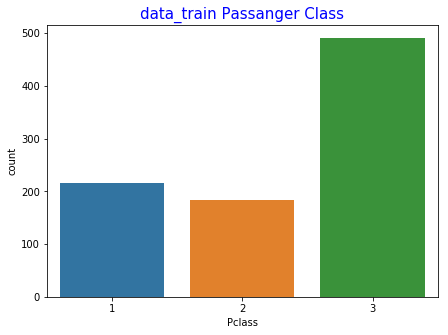

In [12]:
passanger_class = data_train.Pclass
plt.figure(figsize=(7,5))
sns.countplot(passanger_class)
plt.title("data_train Passanger Class",color = 'blue',fontsize=15)
plt.show()

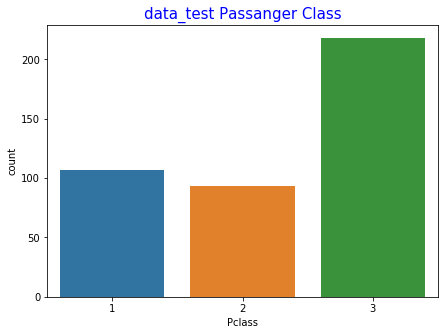

In [13]:
passanger_class = data_test.Pclass
plt.figure(figsize=(7,5))
sns.countplot(passanger_class)
plt.title("data_test Passanger Class",color = 'blue',fontsize=15)
plt.show()

I've splitted according to prefix of name. I've added them becoming a new column. 

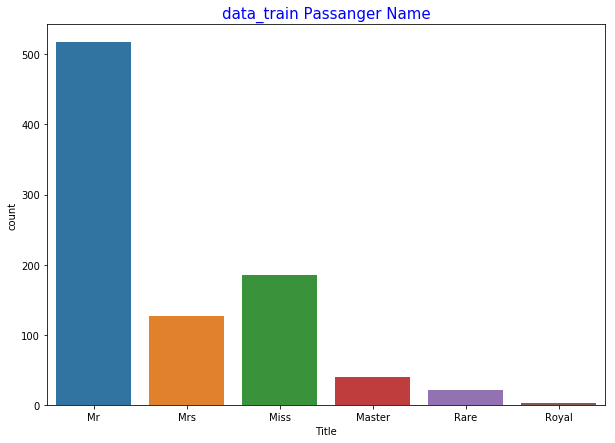

In [14]:
data_train['Title'] = data_train.Name.str.extract(' ([A-Za-z]+)\.', expand=False)

data_train['Title'] = data_train['Title'].replace(['Lady', 'Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Jonkheer', 'Dona'], 'Rare')
data_train['Title'] = data_train['Title'].replace(['Countess', 'Lady', 'Sir'], 'Royal')
data_train['Title'] = data_train['Title'].replace('Mlle', 'Miss')
data_train['Title'] = data_train['Title'].replace('Ms', 'Miss')
data_train['Title'] = data_train['Title'].replace('Mme', 'Mrs')

passanger_name = data_train.Title
plt.figure(figsize=(10,7))
sns.countplot(passanger_name)
plt.title("data_train Passanger Name",color = 'blue',fontsize=15)
plt.show()

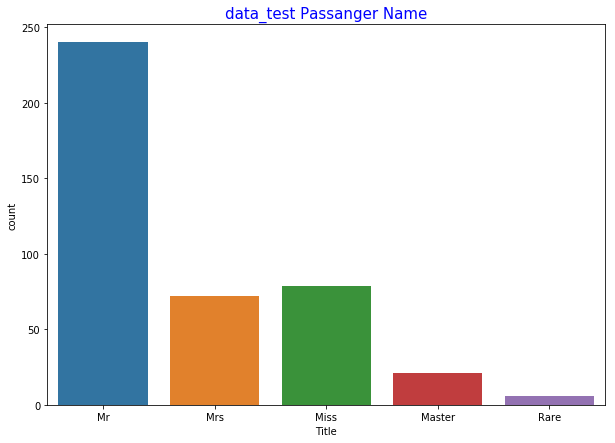

In [15]:
data_test['Title'] = data_test.Name.str.extract(' ([A-Za-z]+)\.', expand=False)

data_test['Title'] = data_test['Title'].replace(['Lady', 'Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Jonkheer', 'Dona'], 'Rare')
data_test['Title'] = data_test['Title'].replace(['Countess', 'Lady', 'Sir'], 'Royal')
data_test['Title'] = data_test['Title'].replace('Mlle', 'Miss')
data_test['Title'] = data_test['Title'].replace('Ms', 'Miss')
data_test['Title'] = data_test['Title'].replace('Mme', 'Mrs')

passanger_name = data_test.Title
plt.figure(figsize=(10,7))
sns.countplot(passanger_name)
plt.title("data_test Passanger Name",color = 'blue',fontsize=15)
plt.show()

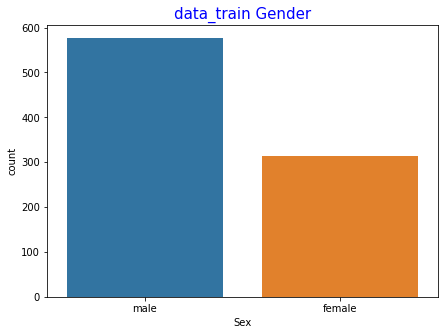

In [16]:
gender = data_train.Sex
plt.figure(figsize=(7,5))
sns.countplot(gender)
plt.title("data_train Gender",color = 'blue',fontsize=15)
plt.show()

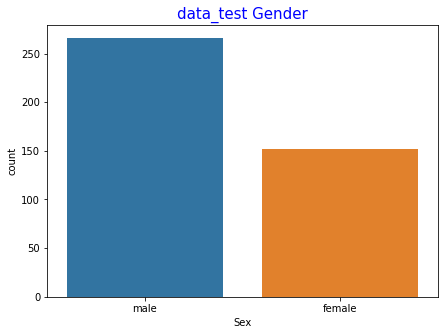

In [17]:
gender = data_test.Sex
plt.figure(figsize=(7,5))
sns.countplot(gender)
plt.title("data_test Gender",color = 'blue',fontsize=15)
plt.show()

I've created age groups. I've added them becoming a new column. 

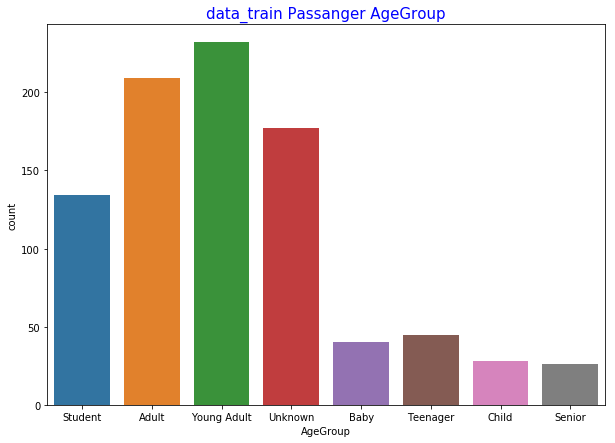

In [18]:
data_train['AgeGroup'] = ["Baby" if (i>=0 and i<5) else "Child" if (i>=5 and i<12) else "Teenager" if (i>=12 and i<18) 
                          else "Student" if(i>=18 and i<24) else "Young Adult" if(i>=24 and i<35) 
                          else "Adult" if(i>=35 and i<60) else "Senior" if(i>=60) else "Unknown" 
                          for i in data_train.Age ]

passanger_ageGroup = data_train.AgeGroup
plt.figure(figsize=(10,7))
sns.countplot(passanger_ageGroup)
plt.title("data_train Passanger AgeGroup",color = 'blue',fontsize=15)
plt.show()

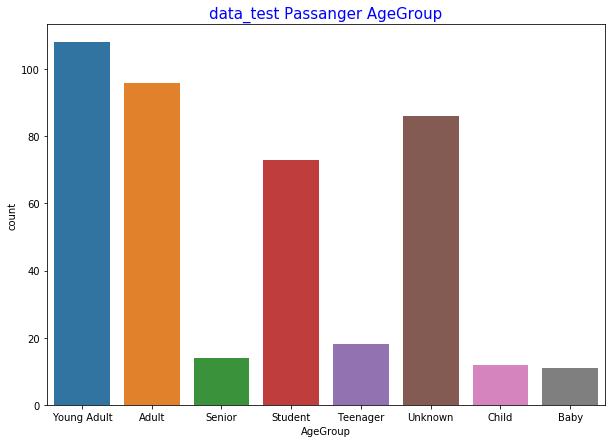

In [19]:
data_test['AgeGroup'] = ["Baby" if (i>=0 and i<5) else "Child" if (i>=5 and i<12) else "Teenager" if (i>=12 and i<18) 
                          else "Student" if(i>=18 and i<24) else "Young Adult" if(i>=24 and i<35) 
                          else "Adult" if(i>=35 and i<60) else "Senior" if(i>=60) else "Unknown" 
                          for i in data_test.Age ]

passanger_ageGroup = data_test.AgeGroup
plt.figure(figsize=(10,7))
sns.countplot(passanger_ageGroup)
plt.title("data_test Passanger AgeGroup",color = 'blue',fontsize=15)
plt.show()

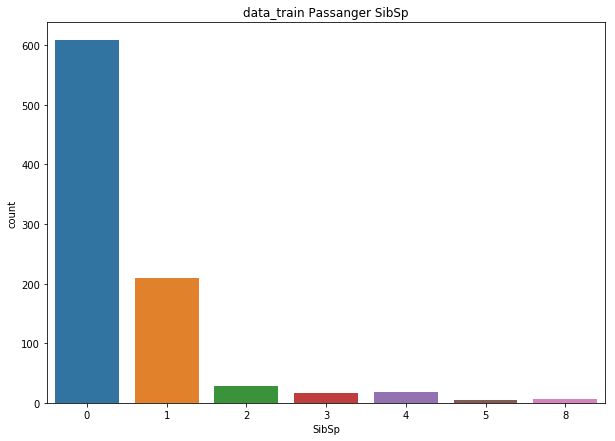

In [20]:
passanger_sibsp = data_train.SibSp
plt.figure(figsize=(10,7))
sns.countplot(passanger_sibsp)
plt.title("data_train Passanger SibSp")
plt.show()

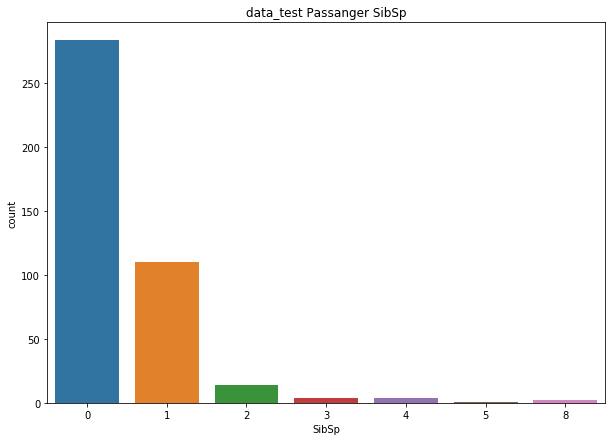

In [21]:
passanger_sibsp = data_test.SibSp
plt.figure(figsize=(10,7))
sns.countplot(passanger_sibsp)
plt.title("data_test Passanger SibSp")
plt.show()

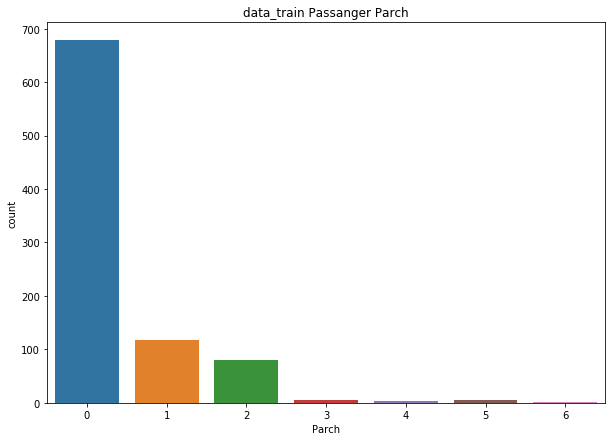

In [22]:
passanger_parch = data_train.Parch
plt.figure(figsize=(10,7))
sns.countplot(passanger_parch)
plt.title("data_train Passanger Parch")
plt.show()

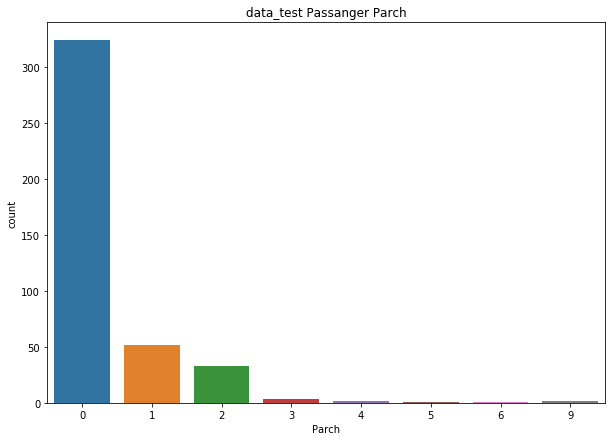

In [23]:
passanger_parch = data_test.Parch
plt.figure(figsize=(10,7))
sns.countplot(passanger_parch)
plt.title("data_test Passanger Parch")
plt.show()

In [24]:
data_train.Fare.describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

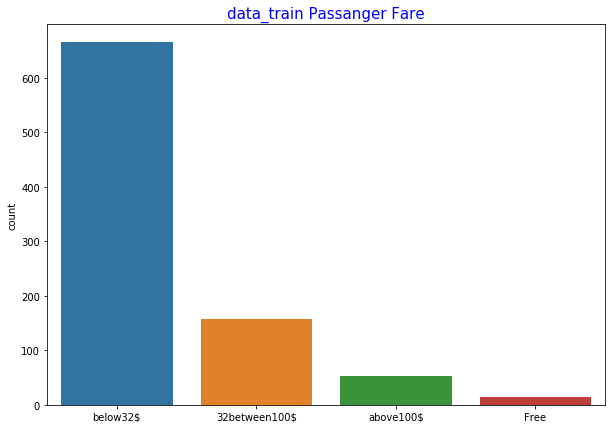

In [25]:
passanger_fare = ['above100$' if i>=100 else '32between100$' if (i<100 and i>=32) else 'Free' if i==0 else 'below32$' for i in data_train.Fare]
plt.figure(figsize=(10,7))
sns.countplot(passanger_fare)
plt.title("data_train Passanger Fare",color = 'blue',fontsize=15)
plt.show()

In [26]:
data_test.Fare.describe()

count    417.000000
mean      35.627188
std       55.907576
min        0.000000
25%        7.895800
50%       14.454200
75%       31.500000
max      512.329200
Name: Fare, dtype: float64

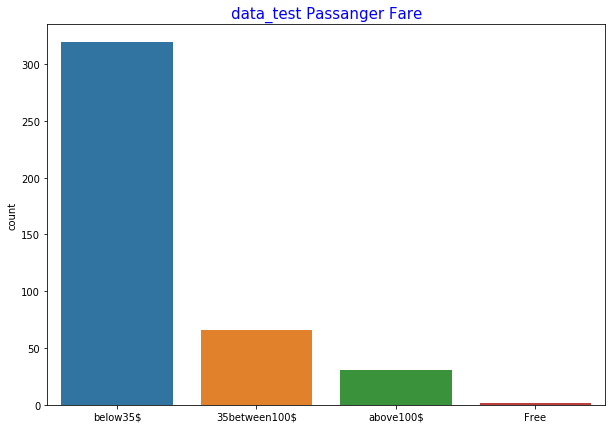

In [27]:
passanger_fare_test = ['above100$' if i>=100 else '35between100$' if (i<100 and i>=35) else 'Free' if i==0 else 'below35$' for i in data_test.Fare]
plt.figure(figsize=(10,7))
sns.countplot(passanger_fare_test)
plt.title("data_test Passanger Fare",color = 'blue',fontsize=15)
plt.show()

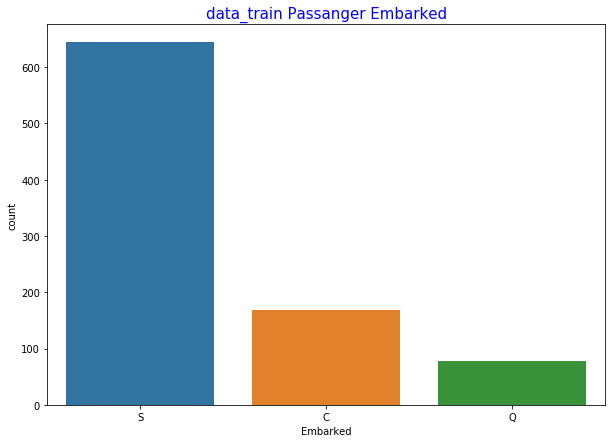

In [28]:
passanger_embarked = data_train.Embarked
plt.figure(figsize=(10,7))
sns.countplot(passanger_embarked)
plt.title("data_train Passanger Embarked",color = 'blue',fontsize=15)
plt.show()

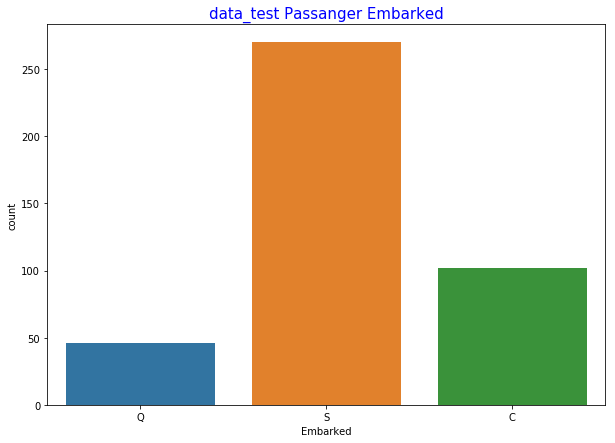

In [29]:
passanger_embarked = data_test.Embarked
plt.figure(figsize=(10,7))
sns.countplot(passanger_embarked)
plt.title("data_test Passanger Embarked",color = 'blue',fontsize=15)
plt.show()

<a id=2></a>
### Cleaning Data

In [30]:
data_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,Student
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,Adult


In [31]:
data_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,AgeGroup
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Mr,Young Adult
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Mrs,Adult
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Mr,Senior
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Mr,Young Adult
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Mrs,Student


I've given a number to classify.

In [32]:
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Royal": 5, "Rare": 6}
data_train['Title'] = data_train['Title'].map(title_mapping)
data_train['Title'] = data_train['Title'].fillna(0)

data_test['Title'] = data_test['Title'].map(title_mapping)
data_test['Title'] = data_test['Title'].fillna(0)

#data_test.Title.head()
#data_train.Title.head()

In [33]:
data_train.Sex = [0 if i=="male" else 1 for i in data_train.Sex]
data_test.Sex = [0 if i=="male" else 1 for i in data_test.Sex]
data_test.Sex.head()
data_train.Sex.head()

0    0
1    1
2    1
3    1
4    0
Name: Sex, dtype: int64

In [34]:
data_train['Age'] = data_train['Age'].fillna(0)
data_test['Age'] = data_test['Age'].fillna(0)
print("Missing train age value count:",pd.isnull(data_test.Age).sum())
print("Missing test age value count:",pd.isnull(data_train.Age).sum())

Missing train age value count: 0
Missing test age value count: 0


In [35]:
title_mapping_age = {"Baby":1, "Child":2, "Teenager":3, "Student":4, "Young Adult":5, "Adult":6, "Senior":7, "Unknow":0}
data_train['AgeGroup'] = data_train['AgeGroup'].map(title_mapping_age)
data_train['AgeGroup'] = data_train['AgeGroup'].fillna(0)
data_test['AgeGroup'] = data_test['AgeGroup'].map(title_mapping_age)
data_test['AgeGroup'] = data_test['AgeGroup'].fillna(0)
#data_test.AgeGroup.head()
#data_train.AgeGroup.head()

I found passengers, which joined with their family or alone, by picking up counts of sibsp and parch.

In [36]:
#train
data_train['FamilySize'] = data_train['SibSp'] + data_train['Parch']
data_train['IsAlone'] = [0 if i==0 else 1 for i in data_train['FamilySize']]# 0 equals alone 1 equals family
data_train["CabinBool"] = (data_train["Cabin"].notnull().astype('int'))
data_train['FareBand'] = [4 if i=='above100$' else 3 if i=='32between100$' else 2 if i=='Free' else 1 for i in passanger_fare]
data_train.Embarked = [0 if i=="S" else 1 if i=="C" else 2 if i=="Q" else 0 for i in data_train.Embarked]
data_train['Embarked'] = data_train['Embarked'].fillna(0)
print(pd.isnull(data_train.Embarked).sum())

#test
data_test['FamilySize'] = data_test['SibSp'] + data_test['Parch']
data_test['IsAlone'] = [0 if i==0 else 1 for i in data_test['FamilySize']]# 0 equals alone 1 equals family
data_test["CabinBool"] = (data_test["Cabin"].notnull().astype('int'))
data_test['FareBand'] = [4 if i=='above100$' else 3 if i=='35between100$' else 2 if i=='Free' else 1 for i in passanger_fare_test]

data_test.Embarked = [0 if i=="S" else 1 if i=="C" else 2 if i=="Q" else 0 for i in data_test.Embarked]
print(pd.isnull(data_test.Embarked).sum())

data_train.head()

0
0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,AgeGroup,FamilySize,IsAlone,CabinBool,FareBand
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0,1,4.0,1,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1,3,6.0,1,1,1,3
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,2,5.0,0,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,0,3,6.0,1,1,1,3
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,0,1,6.0,0,0,0,1


In [37]:
data_train_x = data_train.drop(['PassengerId','Survived','Name','Cabin','SibSp','Parch','Age','Fare','Ticket'],axis=1)
data_train_y = data_train.Survived
data_train_x.head()

,Pclass,Sex,Embarked,Title,AgeGroup,FamilySize,IsAlone,CabinBool,FareBand
0,3,0,0,1,4.0,1,1,0,1
1,1,1,1,3,6.0,1,1,1,3
2,3,1,0,2,5.0,0,0,0,1
3,1,1,0,3,6.0,1,1,1,3
4,3,0,0,1,6.0,0,0,0,1


In [38]:
data_test_x = data_test.drop(['PassengerId','Name','Cabin','SibSp','Parch','Age','Fare','Ticket'],axis=1)
data_test_x.head()

,Pclass,Sex,Embarked,Title,AgeGroup,FamilySize,IsAlone,CabinBool,FareBand
0,3,0,2,1,5.0,0,0,0,1
1,3,1,0,3,6.0,1,1,0,1
2,2,0,2,1,7.0,0,0,0,1
3,3,0,0,1,5.0,0,0,0,1
4,3,1,0,3,4.0,2,1,0,1


In [39]:
#normalization
data_train_x = (data_train_x - np.min(data_train_x))/(np.max(data_train_x)-np.min(data_train_x)).values
data_train_x.head()

,Pclass,Sex,Embarked,Title,AgeGroup,FamilySize,IsAlone,CabinBool,FareBand
0,1.0,0.0,0.0,0.0,0.571429,0.1,1.0,0.0,0.000000
1,0.0,1.0,0.5,0.4,0.857143,0.1,1.0,1.0,0.666667
2,1.0,1.0,0.0,0.2,0.714286,0.0,0.0,0.0,0.000000
3,0.0,1.0,0.0,0.4,0.857143,0.1,1.0,1.0,0.666667
4,1.0,0.0,0.0,0.0,0.857143,0.0,0.0,0.0,0.000000


In [40]:
#normalization
data_test_x = (data_test_x - np.min(data_test_x))/(np.max(data_test_x)-np.min(data_test_x)).values
data_test_x.head()

,Pclass,Sex,Embarked,Title,AgeGroup,FamilySize,IsAlone,CabinBool,FareBand
0,1.0,0.0,1.0,0.0,0.714286,0.0,0.0,0.0,0.0
1,1.0,1.0,0.0,0.4,0.857143,0.1,1.0,0.0,0.0
2,0.5,0.0,1.0,0.0,1.000000,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.714286,0.0,0.0,0.0,0.0
4,1.0,1.0,0.0,0.4,0.571429,0.2,1.0,0.0,0.0


<a id=3.1></a>
###  Logistic Regression Algorithm

In [41]:
from sklearn.model_selection import train_test_split 
x_train, x_test, y_train, y_test = train_test_split(data_train_x,data_train_y,test_size=0.2,random_state=42)
column = ["Logistic Regression","KNN","SVM","Native Bayes","Decision Tree","Random Forest"]
accuracy_list = []
predict_list = []

In [42]:
from sklearn.linear_model import LogisticRegression
reg = LogisticRegression()
reg.fit(x_train,y_train)
print("test accuracy {}".format(reg.score(x_test,y_test)))
accuracy_list.append(reg.score(x_test,y_test))

test accuracy 0.7821229050279329


/opt/conda/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:433: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


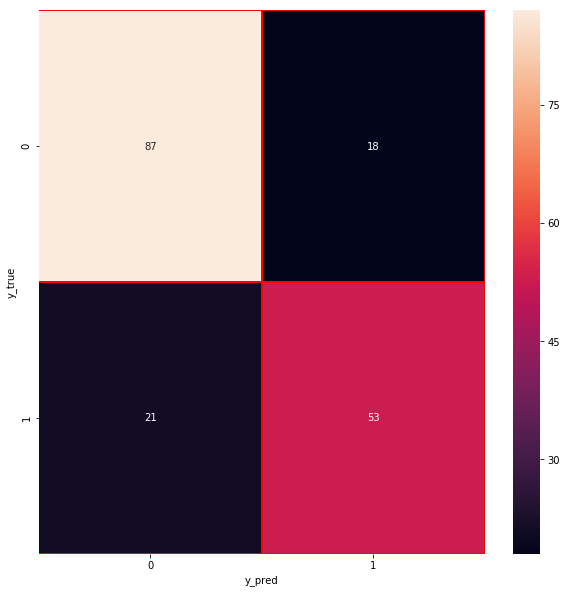

In [43]:
#Estimated number of survivors
y_pred = reg.predict(x_test)
y_true = y_test

#Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true,y_pred)
predict_list.append(cm.item(0)+cm.item(2))

#cm visualization
f, ax = plt.subplots(figsize =(10,10))
sns.heatmap(cm,annot = True,linewidths=0.5,linecolor="red",fmt = ".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

<a id="3.2"></a>
### K-Nearest Neighbour (KNN) Algorithm

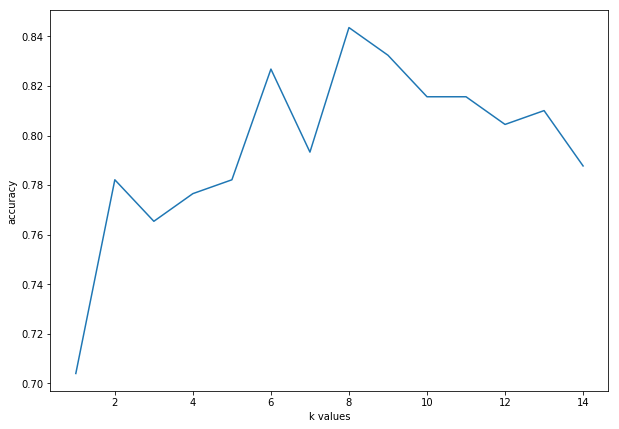

In [44]:
from sklearn.neighbors import KNeighborsClassifier
# find best k value 
score_list = []
for each in range(1,15):
    knn = KNeighborsClassifier(n_neighbors = each)
    knn.fit(x_train,y_train)
    score_list.append(knn.score(x_test,y_test))
 
plt.figure(figsize=(10,7))
plt.plot(range(1,15),score_list)
plt.xlabel("k values")
plt.ylabel("accuracy")
plt.show()

In [45]:
knn = KNeighborsClassifier(n_neighbors = 8)
knn.fit(x_train,y_train)
print(knn.score(x_test,y_test))
accuracy_list.append(knn.score(x_test,y_test))

0.8435754189944135


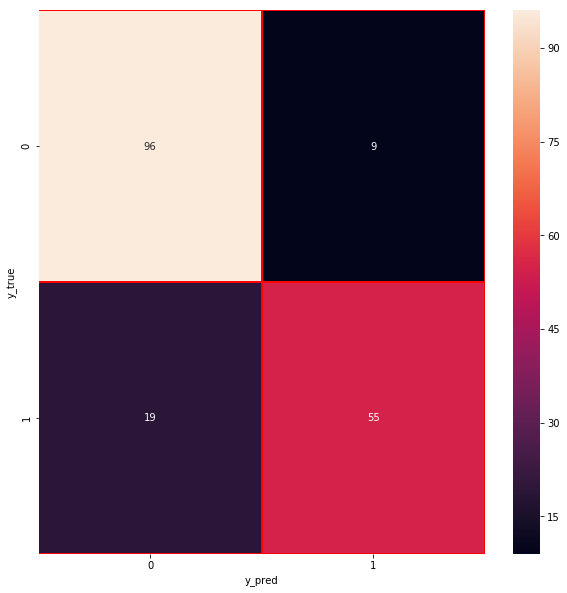

In [46]:
#Estimated number of survivors
y_pred = knn.predict(x_test)
y_true = y_test
cm = confusion_matrix(y_true,y_pred)
predict_list.append(cm.item(0)+cm.item(2))

#cm visualization
f, ax = plt.subplots(figsize =(10,10))
sns.heatmap(cm,annot = True,linewidths=0.5,linecolor="red",fmt = ".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

<a id="3.3"></a>
### Support Vector Machine (SVM) Algorithm

In [47]:
from sklearn.svm import SVC
svm = SVC(random_state = 1)
svm.fit(x_train,y_train)
print("print accuracy of svm algo: ",svm.score(x_test,y_test))
accuracy_list.append(svm.score(x_test,y_test))

print accuracy of svm algo:  0.7821229050279329


/opt/conda/lib/python3.6/site-packages/sklearn/svm/base.py:196: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


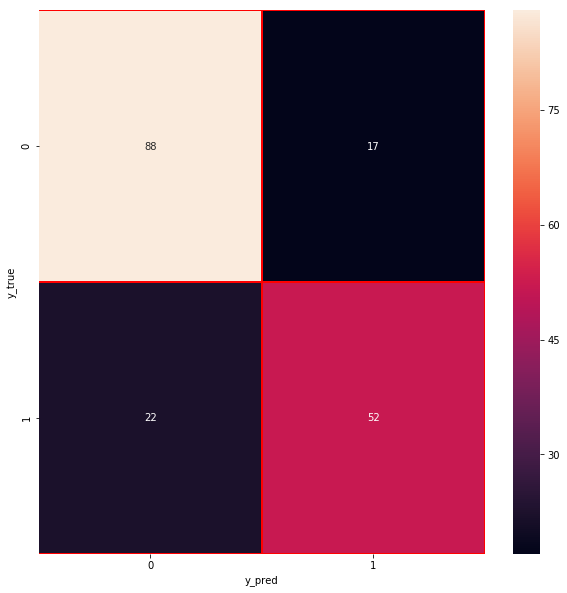

In [48]:
#Estimated number of survivors
y_pred = svm.predict(x_test)
y_true = y_test
cm = confusion_matrix(y_true,y_pred)
predict_list.append(cm.item(0)+cm.item(2))

#cm visualization
f, ax = plt.subplots(figsize =(10,10))
sns.heatmap(cm,annot = True,linewidths=0.5,linecolor="red",fmt = ".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

<a id="3.4"></a>
### Naive Bayes Algorithm

In [49]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(x_train,y_train)
print("print accuracy of naive bayes algo: ",nb.score(x_test,y_test))
accuracy_list.append(nb.score(x_test,y_test))

print accuracy of naive bayes algo:  0.770949720670391


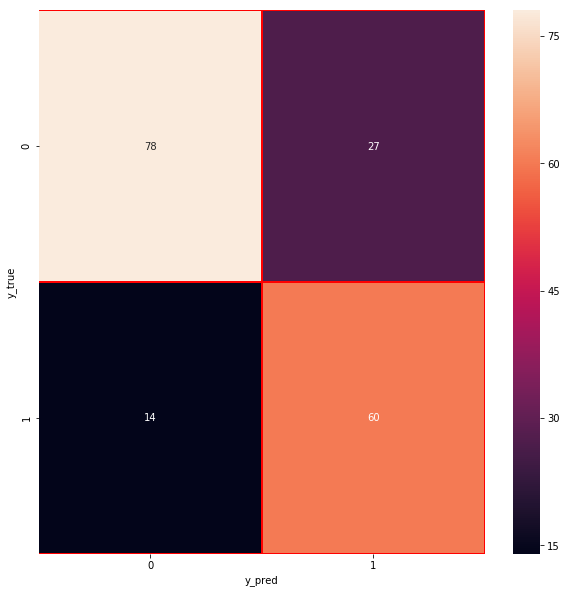

In [50]:
#Estimated number of survivors
y_pred = nb.predict(x_test)
y_true = y_test
cm = confusion_matrix(y_true,y_pred)
predict_list.append(cm.item(0)+cm.item(2)) 

#cm visualization
f, ax = plt.subplots(figsize =(10,10))
sns.heatmap(cm,annot = True,linewidths=0.5,linecolor="red",fmt = ".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

<a id="3.5"></a>
### Decision Tree Algorithm

In [51]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)
print("score: ", dt.score(x_test,y_test))
accuracy_list.append(dt.score(x_test,y_test))

score:  0.8212290502793296


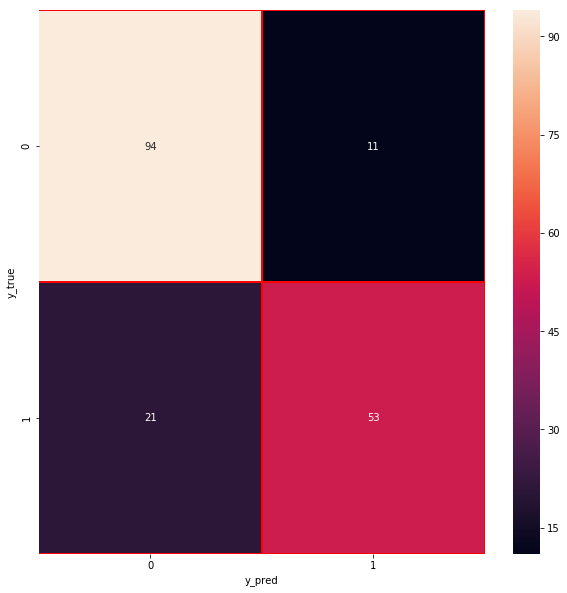

In [52]:
#Estimated number of survivors
y_pred = dt.predict(x_test)
y_true = y_test
cm = confusion_matrix(y_true,y_pred)
predict_list.append(cm.item(0)+cm.item(2))

#cm visualization
f, ax = plt.subplots(figsize =(10,10))
sns.heatmap(cm,annot = True,linewidths=0.5,linecolor="red",fmt = ".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

<a id="3.6"></a> 
### Random Forest Algorithm

In [53]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators = 200,random_state = 42)
rf.fit(x_train,y_train)
print(rf.score(x_test,y_test))
accuracy_list.append(rf.score(x_test,y_test))

0.8379888268156425


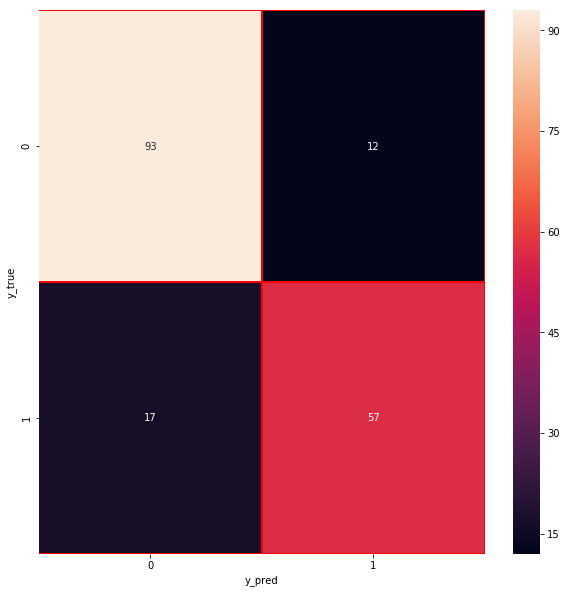

In [54]:
#Estimated number of survivors
y_pred = rf.predict(x_test)
y_true = y_test
cm = confusion_matrix(y_true,y_pred)
predict_list.append(cm.item(0)+cm.item(2))

#cm visualization
f, ax = plt.subplots(figsize =(10,10))
sns.heatmap(cm,annot = True,linewidths=0.5,linecolor="red",fmt = ".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

<a id="3.7"></a>
### Evaluation Classification Models

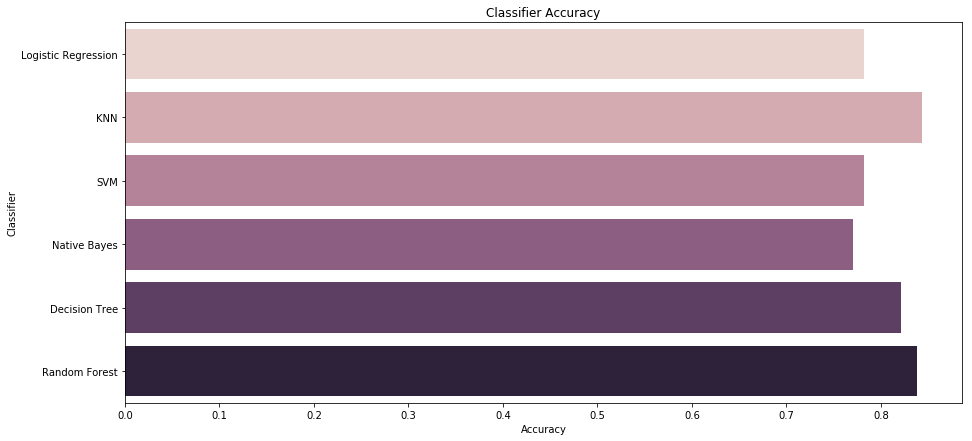

In [55]:
#Classifier Accuracy
f,ax = plt.subplots(figsize = (15,7))
sns.barplot(x=accuracy_list,y=column,palette = sns.cubehelix_palette(len(accuracy_list)))
plt.xlabel("Accuracy")
plt.ylabel("Classifier")
plt.title('Classifier Accuracy')
plt.show()

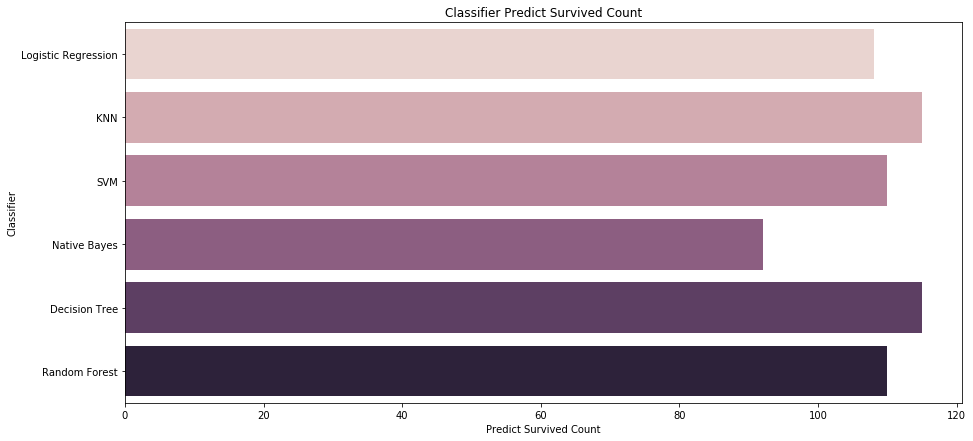

In [56]:
#Classifier Predict Survived Count
f,ax = plt.subplots(figsize = (15,7))
sns.barplot(x=predict_list,y=column,palette = sns.cubehelix_palette(len(accuracy_list)))
plt.xlabel("Predict Survived Count")
plt.ylabel("Classifier")
plt.title('Classifier Predict Survived Count')
plt.show()

In [57]:
#set ids as PassengerId and predict survival 
ids = data_test['PassengerId']
predict = knn.predict(data_test_x)

#set the output as a dataframe and convert to csv file named submission.csv
output = pd.DataFrame({ 'PassengerId' : ids, 'Survived': predict})
output.to_csv('submission.csv', index=False)
